# Outlier Detection with Distance-Based Pruning

This project implements a distance-based outlier detection algorithm from scratch using NumPy. The goal is to identify the top k outliers in a dataset by finding points whose nearest-neighbor distance is largest. Two pruning strategies are implemented and compared to improve computational efficiency.

**Technologies:** Python, NumPy, Matplotlib

## 1. Algorithm Description

The algorithm identifies outliers based on nearest-neighbor distances. For each point, the distance to its closest neighbor is computed. Points with the largest nearest-neighbor distances are considered outliers.

Two pruning strategies are implemented to reduce computation:
- **Pruning 1** — uses a reference point to skip candidate neighbors that cannot possibly be closer than the current best
- **Pruning 2** — skips query points whose nearest-neighbor distance cannot exceed the current k-th largest threshold


## 2. Implementation

In [1]:
from turtledemo.penrose import start

# libraries
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
def nearest_neighbors(query, data, threshold, ref_distances, prune_1, prune_2) -> float:
    """
    For a given query point, find the distance to its nearest neighbor in the dataset.
    Implements two pruning strategies to optimize the search.

    Args:
        query (int): Index of the query point in the dataset.
        data (np.ndarray): The dataset of points.
        threshold (float): The largest NN distance found so far for pruning.
        ref_distances (np.ndarray): Precomputed distances from the reference point to all other points (for pruning).
        prune_1 (bool): Whether to apply the first pruning strategy.
        prune_2 (bool): Whether to apply the second pruning strategy.
    Returns:
        current_best (float): The distance to the nearest neighbor of the query point.
    """
    # your implementation starts here:
    n = data.shape[0]
    current_best = np.inf

    for i in range(n):
        if i != query:
            
            if prune_1:
                if ref_distances[i] + ref_distances[query] < threshold:
                    # prune step 1
                    return 0

            d = np.linalg.norm(data[i] - data[query])
            if prune_2 and d < threshold:
                # prune step 2
                return 0
            if d < current_best:
                current_best = d

    return float(current_best)

In [3]:
def find_outliers(data, k, prune_1, prune_2) -> dict:
    """
    Identify the outlier in the dataset based on the nearest neighbor distances.

    Args:
        data (np.ndarray): The dataset of points.
        k (int): The number of top outliers to identify.
        prune_1 (bool): Whether to apply the first pruning strategy.
        prune_2 (bool): Whether to apply the second pruning strategy.
    Returns:
        answer (dict): A dictionary containing:
            - "outliers": List with the index of the identified outliers.
            - "nn_distances": List of nearest neighbor distance for each outlier.
            - "time": Time taken to execute the outlier detection.
    """
    # please use this dict to store your final answer
    answer = {
        "outliers": [],
        "nn_distances": [],
        "time": None
    }

    # your implementation starts here:
    start=time.time()
    n = data.shape[0]
    outlier_idx = -1
    topk = []

    # randomly choose a reference object
    ref_index = np.random.randint(0, data.shape[0])
    ref_object = data[ref_index]

    # compute the distance between the reference object and all other objects
    ref_distances = np.linalg.norm(data - ref_object, axis=1)

    for i in range(n):
        if len(topk) < k:
            best_so_far = np.inf
        else:
            min_distance = topk[0][0]
            for nn_dist, idx in topk:
                if nn_dist < min_distance:
                    min_distance = nn_dist
            best_so_far = min_distance

        nn_dist = nearest_neighbors(i, data, best_so_far, ref_distances, prune_1, prune_2)
        if len(topk) < k:
            topk.append((nn_dist, i))
        elif nn_dist > best_so_far:
            min_distance = topk[0][0]
            min_index = 0
            for j in range(len(topk)):
                if topk[j][0] < min_distance:
                    min_distance = topk[j][0]
                    min_index = j
            topk.pop(min_index)
            topk.append((nn_dist, i))

    end = time.time()
    answer["time"] = end - start

    for nn_dist, idx in topk:
        answer["outliers"].append(idx)
        answer["nn_distances"].append(nn_dist)
    
    return answer

## 3. Experiments and Analysis

The algorithm is evaluated across four configurations on a 5,000-sample subset:
- **No pruning** — brute force baseline
- **Pruning 1 only** — reference point pruning
- **Pruning 2 only** — threshold-based pruning
- **Both pruning steps** — combined

For each configuration we report execution time, identified outlier indices, and nearest-neighbor distances. All configurations are verified to return identical outliers.

No pruning: 54.6s
Pruning 1: 56.6s
Pruning 2: 12.1s
Both: 13.1s

Verification:
  Original Outliers: [4261, 4404, 4559, 4673]
  Result Outlier:        [4261, 4404, 4559, 4673]
  Match: Yes

  No pruning: [4261, 4404, 4559, 4673]
  Pruning 1: [4261, 4404, 4559, 4673]
  Pruning 2: [4261, 4404, 4559, 4673]
  Both: [4261, 4404, 4559, 4673]

Top 4 Outliers:
 1 - Point 4261: 90.4835
 2 - Point 4404: 92.0828
 3 - Point 4559: 91.6544
 4 - Point 4673: 91.6297



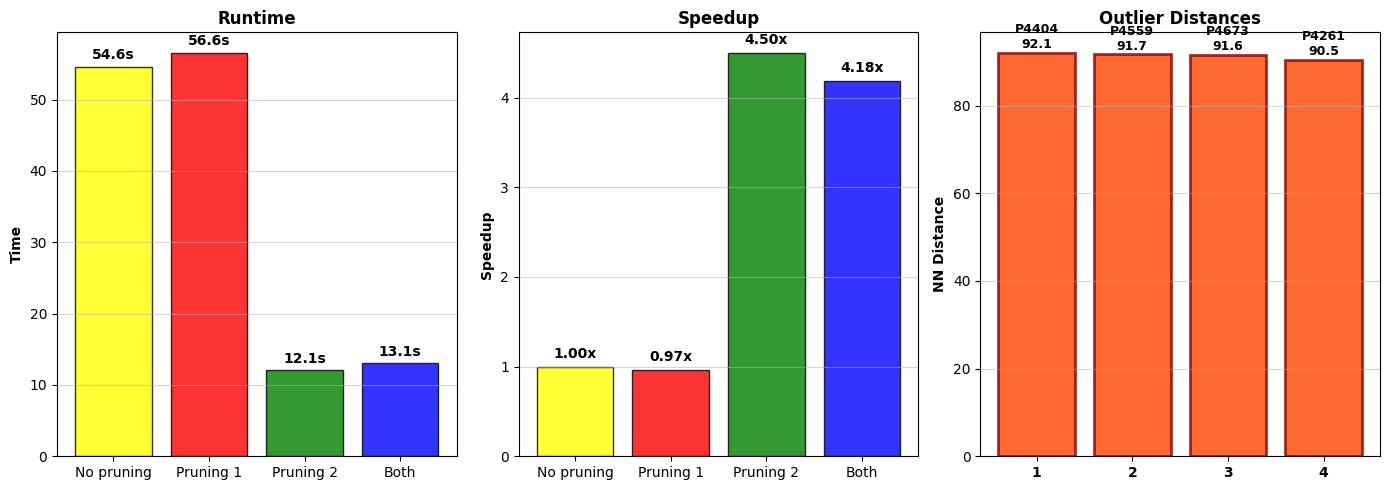

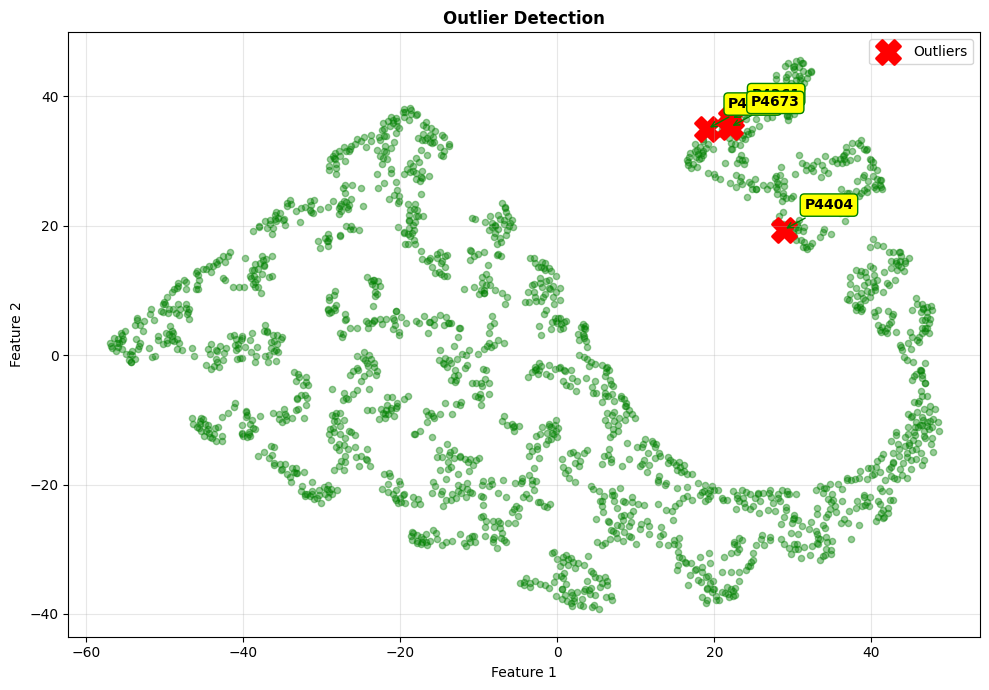

In [4]:
data_full = np.loadtxt('../data/assignment_4_data.txt')
data = data_full[:5000]
k = 4
tests = [("No pruning", False, False), ("Pruning 1", True, False),
         ("Pruning 2", False, True), ("Both", True, True)]
results = {}

for name, p1, p2 in tests:
    np.random.seed(10)
    results[name] = find_outliers(data, k, p1, p2)

for name in results:
    print(f"{name}: {results[name]['time']:.1f}s")

print()

np.random.seed(10)
verifyresult = find_outliers(data, k, True, True)
outliers = sorted(results["Both"]["outliers"])
verifyoutliers = sorted(verifyresult["outliers"])

print("Verification:")
print(f"  Original Outliers: {outliers}")
print(f"  Result Outlier:        {verifyoutliers}")
print(f"  Match: {'Yes' if outliers == verifyoutliers else 'No'}")
print()

for name in results:
    found = sorted(results[name]["outliers"])
    print(f"  {name}: {found}")
print()

print("Top 4 Outliers:")
for rank, idx in enumerate(outliers, 1):
    dist = results["Both"]["nn_distances"][results["Both"]["outliers"].index(idx)]
    print(f" {rank} - Point {idx}: {dist:.4f}")
print()

import matplotlib.pyplot as plt
names = [n for n, _, _ in tests]
times = [results[n]["time"] for n in names]
speedups = [times[0]/t for t in times]
colors = ['yellow', 'red', 'green', 'blue']
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

#Time
ax1.bar(names, times, color=colors, alpha=0.8, edgecolor='black')
for i, t in enumerate(times):
    ax1.text(i, t + 1, f'{t:.1f}s', ha='center', fontweight='bold')
ax1.set_ylabel('Time', fontweight='bold')
ax1.set_title('Runtime', fontweight='bold')
ax1.grid(axis='y', alpha=0.5)

#Speed
ax2.bar(names, speedups, color=colors, alpha=0.8, edgecolor='black')
for i, s in enumerate(speedups):
    ax2.text(i, s + 0.1, f'{s:.2f}x', ha='center', fontweight='bold')
ax2.set_ylabel('Speedup', fontweight='bold')
ax2.set_title('Speedup', fontweight='bold')
ax2.grid(axis='y', alpha=0.5)

#Outlier
dists = [results["Both"]["nn_distances"][results["Both"]["outliers"].index(idx)]
         for idx in sorted(outliers)]
sorteddists = sorted(dists, reverse=True)
sortedoutliers = sorted(outliers, key=lambda x:
    results["Both"]["nn_distances"][results["Both"]["outliers"].index(x)], reverse=True)
ax3.bar(range(4), sorteddists, color='orangered', alpha=0.8, edgecolor='darkred', linewidth=2)
for i, (idx, d) in enumerate(zip(sortedoutliers, sorteddists)):
    ax3.text(i, d + 1, f'P{idx}\n{d:.1f}', ha='center', fontweight='bold', fontsize=9)
ax3.set_xticks(range(4))
ax3.set_xticklabels(['1', '2', '3', '4'], fontweight='bold')
ax3.set_ylabel('NN Distance', fontweight='bold')
ax3.set_title('Outlier Distances', fontweight='bold')
ax3.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()


from sklearn.manifold import TSNE
np.random.seed(10)
sample_idx = np.unique(np.concatenate([np.random.choice(len(data), 2000, replace=False), outliers]))
data_2d = TSNE(n_components=2, random_state=10).fit_transform(data[sample_idx])
is_out = np.isin(sample_idx, outliers)

plt.figure(figsize=(10, 7))
plt.scatter(data_2d[~is_out, 0], data_2d[~is_out, 1], c='green', s=20, alpha=0.4)
plt.scatter(data_2d[is_out, 0], data_2d[is_out, 1], c='red', s=300, marker='X',
           edgecolors='red', linewidths=2, label='Outliers')

for idx in outliers:
    pos = np.where(sample_idx == idx)[0][0]
    plt.annotate(f'P{idx}', (data_2d[pos, 0], data_2d[pos, 1]), xytext=(15, 15),
                textcoords='offset points', fontweight='bold',
                bbox=dict(boxstyle='round', fc='yellow', ec='green'),
                arrowprops=dict(arrowstyle='->', color='green'))

plt.title('Outlier Detection', fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Verification

The cells below verify the implementation against known expected outputs to confirm correctness across all pruning configurations.

In [5]:
# =============================================================================
# TEST CELL 1: Basic Functionality Tests
# =============================================================================

print("="*70)
print("TEST 1: Basic Functionality")
print("="*70)

# Create a simple test dataset
test_data_simple = np.array([
    [0, 0],
    [1, 1],
    [1, 0],
    [0, 1],
    [100, 100]  # This should be the outlier (index 4)
])

# Test with all pruning configurations
print("\nTesting with simple dataset (outlier should be at index 4):")
configs = [
    ("No pruning", False, False),
    ("Pruning 1 only", True, False),
    ("Pruning 2 only", False, True),
    ("Both pruning", True, True)
]

results = []
for name, prune_1, prune_2 in configs:
    np.random.seed(42)  # Use same seed for fair comparison
    answer = find_outliers(test_data_simple, k=1, prune_1=prune_1, prune_2=prune_2)
    outlier_idx = answer["outliers"][0]
    outlier_dist = answer["nn_distances"][0]
    results.append((name, outlier_idx, outlier_dist))
    print(f"{name:20s}: Outlier at index {outlier_idx}, distance = {outlier_dist:.2f}")

# Check consistency
outlier_indices = [r[1] for r in results]
if len(set(outlier_indices)) == 1 and outlier_indices[0] == 4:
    print("\n✓ PASSED: All configurations correctly identified the outlier at index 4")
else:
    print(f"\n✗ FAILED: Inconsistent results or wrong outlier. Got indices: {outlier_indices}")

# =============================================================================
# TEST CELL 2: Consistency Across Pruning Methods
# =============================================================================

print("\n" + "="*70)
print("TEST 2: Consistency Across Pruning Methods")
print("="*70)

# Test on a 1D dataset
test_data_1d = np.array([[1], [2], [3], [4], [50]])

print("\nTesting 1D dataset (outlier should be at index 4):")
np.random.seed(42)
answer_no_prune = find_outliers(test_data_1d, k=1, prune_1=False, prune_2=False)
idx_no_prune = answer_no_prune["outliers"][0]

np.random.seed(42)
answer_both_prune = find_outliers(test_data_1d, k=1, prune_1=True, prune_2=True)
idx_both_prune = answer_both_prune["outliers"][0]

print(f"Without pruning: index {idx_no_prune}")
print(f"With both pruning: index {idx_both_prune}")

if idx_no_prune == idx_both_prune == 4:
    print("✓ PASSED: Consistent results across pruning methods")
else:
    print("✗ FAILED: Inconsistent results")

# =============================================================================
# TEST CELL 3: Nearest Neighbor Function Test
# =============================================================================

print("\n" + "="*70)
print("TEST 3: Nearest Neighbor Function")
print("="*70)

# Test nearest_neighbor function directly
test_points = np.array([[0, 0], [3, 4], [6, 8]])  # 3-4-5 triangle scaled

ref_index = 0
ref_distances = np.linalg.norm(test_points - test_points[ref_index], axis=1)

print("\nTest data: [[0, 0], [3, 4], [6, 8]]")
print("Reference point: [0, 0]")

# For point 2 (index 2), nearest neighbor should be point 1
# Distance should be sqrt((6-3)^2 + (8-4)^2) = sqrt(9 + 16) = 5
nn_dist = nearest_neighbors(query=2, data=test_points, threshold=float('inf'),
                            ref_distances=ref_distances, prune_1=False, prune_2=False)

expected_dist = 5.0
print(f"\nNearest neighbor distance for point [6, 8]: {nn_dist:.2f}")
print(f"Expected distance: {expected_dist:.2f}")

if abs(nn_dist - expected_dist) < 0.01:
    print("✓ PASSED: Nearest neighbor calculation is correct")
else:
    print("✗ FAILED: Nearest neighbor calculation is incorrect")

# =============================================================================
# TEST CELL 4: Pruning Effectiveness Test
# =============================================================================

print("\n" + "="*70)
print("TEST 4: Pruning Effectiveness")
print("="*70)

# Test that pruning returns 0 when appropriate
test_cluster = np.array([[0, 0], [1, 0], [0, 1], [1, 1], [100, 100]])

ref_index = 0
ref_distances = np.linalg.norm(test_cluster - test_cluster[ref_index], axis=1)

print("\nTesting that pruning returns 0 for non-outliers when threshold is large:")

# For point 1 (close to others), with large threshold, should be pruned
nn_dist_pruned = nearest_neighbors(query=1, data=test_cluster, threshold=1000,
                                  ref_distances=ref_distances, prune_1=True, prune_2=False)

print(f"Nearest neighbor distance for point 1 with pruning (threshold=1000): {nn_dist_pruned}")

if nn_dist_pruned == 0:
    print("✓ PASSED: Pruning correctly returns 0 for non-outlier")
else:
    print("✗ FAILED: Pruning should have returned 0")

# =============================================================================
# TEST CELL 5: Reproducibility Test
# =============================================================================

print("\n" + "="*70)
print("TEST 5: Reproducibility")
print("="*70)

test_data_repro = np.array([[1, 1], [2, 2], [3, 3], [50, 50]])

print("\nRunning same test twice with same random seed:")

np.random.seed(999)
answer1 = find_outliers(test_data_repro, k=1, prune_1=True, prune_2=True)
idx1 = answer1["outliers"][0]
dist1 = answer1["nn_distances"][0]

np.random.seed(999)
answer2 = find_outliers(test_data_repro, k=1, prune_1=True, prune_2=True)
idx2 = answer2["outliers"][0]
dist2 = answer2["nn_distances"][0]

print(f"Run 1: Outlier at index {idx1}, distance = {dist1:.6f}")
print(f"Run 2: Outlier at index {idx2}, distance = {dist2:.6f}")

if idx1 == idx2 and abs(dist1 - dist2) < 1e-10:
    print("✓ PASSED: Results are reproducible with same random seed")
else:
    print("✗ FAILED: Results are not reproducible")

TEST 1: Basic Functionality

Testing with simple dataset (outlier should be at index 4):
No pruning          : Outlier at index 4, distance = 140.01
Pruning 1 only      : Outlier at index 4, distance = 140.01
Pruning 2 only      : Outlier at index 4, distance = 140.01
Both pruning        : Outlier at index 4, distance = 140.01

✓ PASSED: All configurations correctly identified the outlier at index 4

TEST 2: Consistency Across Pruning Methods

Testing 1D dataset (outlier should be at index 4):
Without pruning: index 4
With both pruning: index 4
✓ PASSED: Consistent results across pruning methods

TEST 3: Nearest Neighbor Function

Test data: [[0, 0], [3, 4], [6, 8]]
Reference point: [0, 0]

Nearest neighbor distance for point [6, 8]: 5.00
Expected distance: 5.00
✓ PASSED: Nearest neighbor calculation is correct

TEST 4: Pruning Effectiveness

Testing that pruning returns 0 for non-outliers when threshold is large:
Nearest neighbor distance for point 1 with pruning (threshold=1000): 0
✓

In [6]:
# =============================================================================
# TEST CELL 6: Multiple Outliers (k > 1) - Basic Functionality
# =============================================================================

print("\n" + "="*70)
print("TEST 6: Multiple Outliers (k=2) - Basic Functionality")
print("="*70)

# Create test dataset with 2 clear outliers
test_data_k2 = np.array([
    [0, 0],
    [1, 1],
    [1, 0],
    [0, 1],
    [0.5, 0.5],
    [100, 100],  # outlier 1 (index 5)
    [200, 200]   # outlier 2 (index 6)
])

print("\nTesting with k=2 (outliers should be at indices 5 and 6):")
np.random.seed(42)
answer_k2 = find_outliers(test_data_k2, k=2, prune_1=False, prune_2=False)
outliers_k2 = set(answer_k2["outliers"])
distances_k2 = answer_k2["nn_distances"]

print(f"Found outliers at indices: {sorted(outliers_k2)}")
print(f"Distances: {distances_k2}")

if outliers_k2 == {5, 6}:
    print("✓ PASSED: Correctly identified both outliers")
else:
    print(f"✗ FAILED: Expected indices {{5, 6}}, got {outliers_k2}")

# =============================================================================
# TEST CELL 7: Multiple Outliers (k=3) - Ordering and Distance Verification
# =============================================================================

print("\n" + "="*70)
print("TEST 7: Multiple Outliers (k=3) - Ordering Verification")
print("="*70)

# Create test dataset with 3 outliers at different distances
test_data_k3 = np.array([
    [0, 0],
    [1, 0],
    [0, 1],
    [10, 10],   # small outlier (index 3)
    [50, 50],   # medium outlier (index 4)
    [100, 100]  # large outlier (index 5)
])

print("\nTesting with k=3 (outliers at indices 3, 4, 5):")
np.random.seed(42)
answer_k3 = find_outliers(test_data_k3, k=3, prune_1=False, prune_2=False)
outliers_k3 = answer_k3["outliers"]
distances_k3 = answer_k3["nn_distances"]

print(f"Found outliers: {outliers_k3}")
print(f"With distances: {[f'{d:.2f}' for d in distances_k3]}")

# Verify all three outliers are found
outliers_set = set(outliers_k3)
if outliers_set == {3, 4, 5}:
    print("✓ PASSED: All three outliers identified")

    # Verify distances are in ascending order (priority queue extracts smallest first)
    if distances_k3 == sorted(distances_k3):
        print("✓ PASSED: Distances are in ascending order")
    else:
        print("✗ FAILED: Distances should be in ascending order")
else:
    print(f"✗ FAILED: Expected indices {{3, 4, 5}}, got {outliers_set}")

# =============================================================================
# TEST CELL 8: Consistency Across Pruning Methods (k > 1)
# =============================================================================

print("\n" + "="*70)
print("TEST 8: Consistency Across Pruning Methods with k=3")
print("="*70)

test_data_consistency = np.array([
    [0, 0], [1, 1], [0.5, 0.5],
    [20, 20], [30, 30], [40, 40]
])

print("\nTesting that all pruning configurations find same outliers:")

configs_k3 = [
    ("No pruning", False, False),
    ("Pruning 1 only", True, False),
    ("Pruning 2 only", False, True),
    ("Both pruning", True, True)
]

all_results = []
for name, prune_1, prune_2 in configs_k3:
    np.random.seed(999)  # Same seed for all
    answer = find_outliers(test_data_consistency, k=3, prune_1=prune_1, prune_2=prune_2)
    outliers_set = set(answer["outliers"])
    all_results.append((name, outliers_set))
    print(f"{name:20s}: outliers = {sorted(outliers_set)}")

# Check all methods found the same outliers
outlier_sets = [r[1] for r in all_results]
if len(set(map(frozenset, outlier_sets))) == 1:
    print("✓ PASSED: All pruning methods found the same outliers")
else:
    print("✗ FAILED: Different pruning methods found different outliers")

# =============================================================================
# TEST CELL 9: Edge Case - k equals n-1
# =============================================================================

print("\n" + "="*70)
print("TEST 9: Edge Case - k = n-1 (all but one point)")
print("="*70)

test_data_edge = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5]])

print(f"\nTesting with k={len(test_data_edge)-1} (finding all but one point):")
np.random.seed(42)
answer_edge = find_outliers(test_data_edge, k=len(test_data_edge)-1,
                            prune_1=False, prune_2=False)
num_found = len(answer_edge["outliers"])

print(f"Expected {len(test_data_edge)-1} outliers, found {num_found}")

if num_found == len(test_data_edge) - 1:
    print("✓ PASSED: Correctly found k=n-1 outliers")
else:
    print(f"✗ FAILED: Expected {len(test_data_edge)-1} outliers, got {num_found}")

# =============================================================================
# TEST CELL 10: Reproducibility with k > 1
# =============================================================================

print("\n" + "="*70)
print("TEST 10: Reproducibility with k=3")
print("="*70)

test_data_repro_k3 = np.array([
    [1, 1], [2, 2], [3, 3],
    [50, 50], [60, 60], [70, 70]
])

print("\nRunning same test twice with same random seed:")

np.random.seed(777)
answer1_k3 = find_outliers(test_data_repro_k3, k=3, prune_1=True, prune_2=True)
outliers1 = sorted(answer1_k3["outliers"])
distances1 = sorted(answer1_k3["nn_distances"])

np.random.seed(777)
answer2_k3 = find_outliers(test_data_repro_k3, k=3, prune_1=True, prune_2=True)
outliers2 = sorted(answer2_k3["outliers"])
distances2 = sorted(answer2_k3["nn_distances"])

print(f"Run 1: Outliers = {outliers1}")
print(f"Run 2: Outliers = {outliers2}")

if outliers1 == outliers2 and all(abs(d1 - d2) < 1e-10 for d1, d2 in zip(distances1, distances2)):
    print("✓ PASSED: Results are reproducible with k=3")
else:
    print("✗ FAILED: Results differ between runs")


TEST 6: Multiple Outliers (k=2) - Basic Functionality

Testing with k=2 (outliers should be at indices 5 and 6):
Found outliers at indices: [5, 6]
Distances: [140.0071426749364, 141.4213562373095]
✓ PASSED: Correctly identified both outliers

TEST 7: Multiple Outliers (k=3) - Ordering Verification

Testing with k=3 (outliers at indices 3, 4, 5):
Found outliers: [3, 4, 5]
With distances: ['13.45', '56.57', '70.71']
✓ PASSED: All three outliers identified
✓ PASSED: Distances are in ascending order

TEST 8: Consistency Across Pruning Methods with k=3

Testing that all pruning configurations find same outliers:
No pruning          : outliers = [3, 4, 5]
Pruning 1 only      : outliers = [3, 4, 5]
Pruning 2 only      : outliers = [3, 4, 5]
Both pruning        : outliers = [3, 4, 5]
✓ PASSED: All pruning methods found the same outliers

TEST 9: Edge Case - k = n-1 (all but one point)

Testing with k=4 (finding all but one point):
Expected 4 outliers, found 4
✓ PASSED: Correctly found k=n-1 o